In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
from tqdm import tqdm

## Lucas Kanade Optic Flow

In [2]:
img1 = cv2.imread('TestSeq/Shift0.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('TestSeq/ShiftR2.png', cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread('TestSeq/ShiftR5U5.png', cv2.IMREAD_GRAYSCALE) 

Text(0.5, 1.0, 'ShiftR5U5.png')

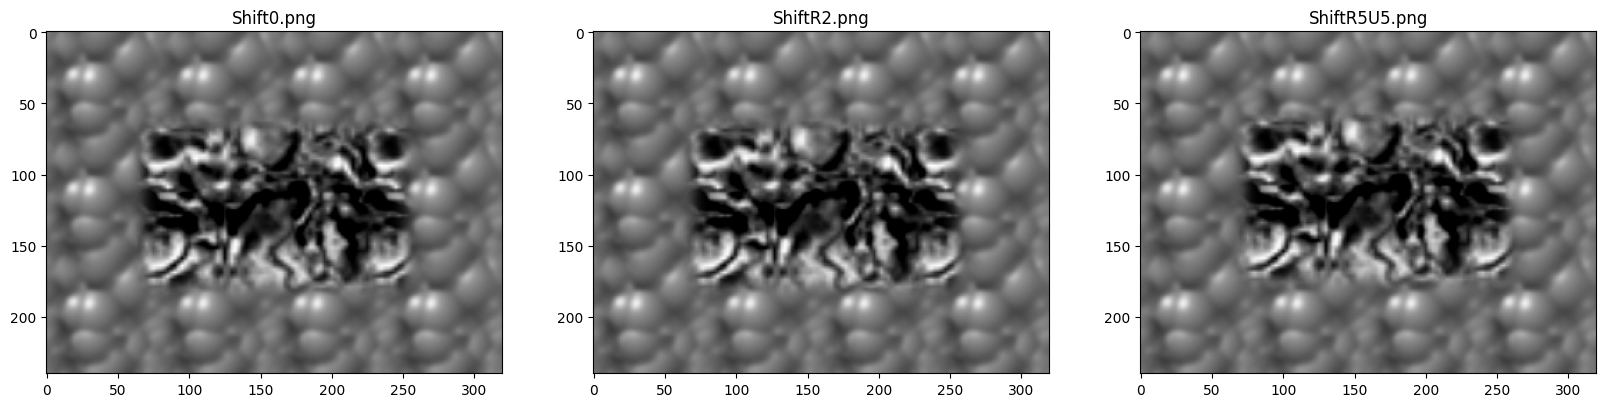

In [3]:
plt.figure(figsize=(20,20))
plt.subplot(131)
plt.imshow(img1, cmap='gray')
plt.title('Shift0.png')
plt.subplot(132)
plt.imshow(img2, cmap='gray')
plt.title('ShiftR2.png')
plt.subplot(133)
plt.imshow(img3, cmap='gray')
plt.title('ShiftR5U5.png')

In [4]:
smooth_img1 = cv2.GaussianBlur(img1, (31, 31), 2)
smooth_img2 = cv2.GaussianBlur(img2, (31, 31), 2)

In [5]:
def find_img_derivatives(img1, img2):
    Ix = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)
    It = img2.astype(np.float64) - img1.astype(np.float64)
    return Ix, Iy, It

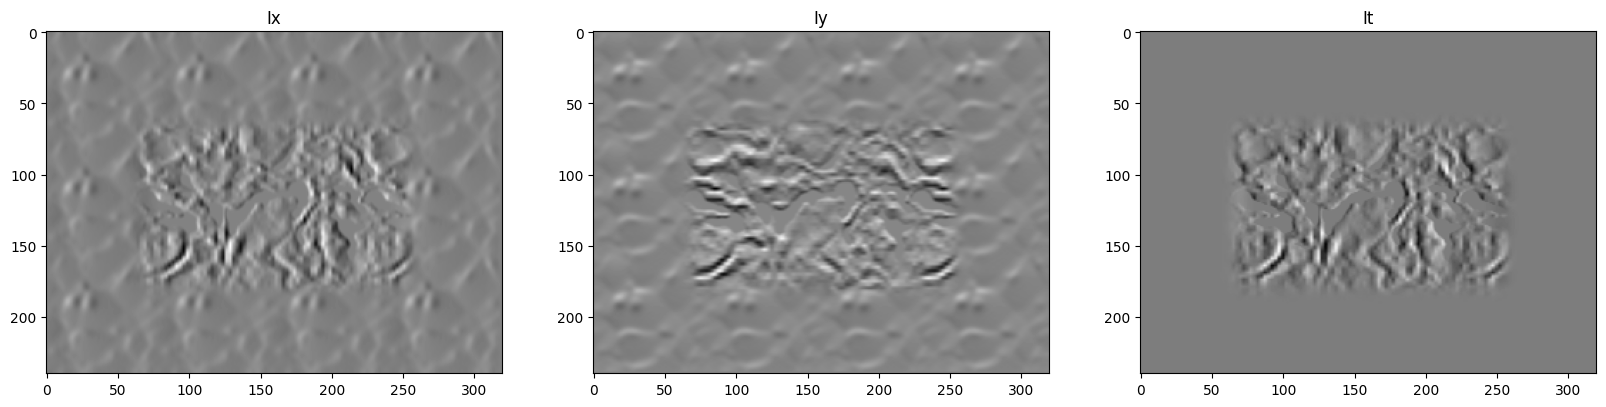

In [6]:
Ix, Iy, It = find_img_derivatives(img1, img2)
plt.figure(figsize=(20,20))
plt.subplot(131)
plt.imshow(Ix, cmap='gray')
plt.title('Ix')
plt.subplot(132)
plt.imshow(Iy, cmap='gray')
plt.title('Iy')
plt.subplot(133)
plt.imshow(It, cmap='gray')
plt.title('It')
plt.show()

In [7]:
def find_LK_optic_flow(Ix, Iy, It, x, y, box_size):
    A = np.zeros((2, 2))
    b = np.zeros((2, 1))
    Ix_box = Ix[y-box_size:y+box_size+1, x-box_size:x+box_size+1]
    Iy_box = Iy[y-box_size:y+box_size+1, x-box_size:x+box_size+1]
    It_box = It[y-box_size:y+box_size+1, x-box_size:x+box_size+1]
    A[0, 0] = np.sum(Ix_box**2)
    A[0, 1] = np.sum(Ix_box*Iy_box)
    A[1, 0] = np.sum(Ix_box*Iy_box)
    A[1, 1] = np.sum(Iy_box**2)
    b[0] = -np.sum(Ix_box*It_box)
    b[1] = -np.sum(Iy_box*It_box)
    A += np.eye(2) * 1e-4 
    V = np.linalg.inv(A) @ b
    return V

In [8]:
def LK_optic_flow(img1, img2, box_size):
    Ix, Iy, It = find_img_derivatives(img1, img2)
    Ix, Iy, It = cv2.GaussianBlur(Ix, (5, 5), 2), cv2.GaussianBlur(
        Iy, (5, 5), 2), cv2.GaussianBlur(It, (5, 5), 2)
    V = np.zeros((img1.shape[0], img1.shape[1], 2))
    for y in tqdm(range(box_size, img1.shape[0]-box_size), desc='Calculating Optical Flow'):
        for x in range(box_size, img1.shape[1]-box_size):
            V_xy = find_LK_optic_flow(Ix, Iy, It, x, y, box_size)
            V[y, x] = V_xy.reshape(V_xy.shape[0])
    return V

Calculating Optical Flow: 100%|██████████| 220/220 [00:01<00:00, 146.23it/s]


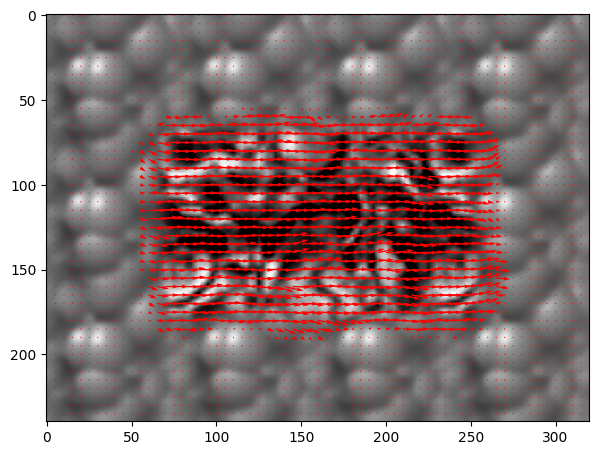

In [9]:
V = LK_optic_flow(img1, img2, 10)
plt.figure(figsize=(7, 8))
plt.imshow(img1, cmap='gray')
plt.quiver(np.arange(0, img1.shape[1], 5), np.arange(0, img1.shape[0], 5), V[::5, ::5, 0], V[::5, ::5, 1], color='r')
plt.show()

Calculating Optical Flow: 100%|██████████| 206/206 [00:01<00:00, 157.66it/s]


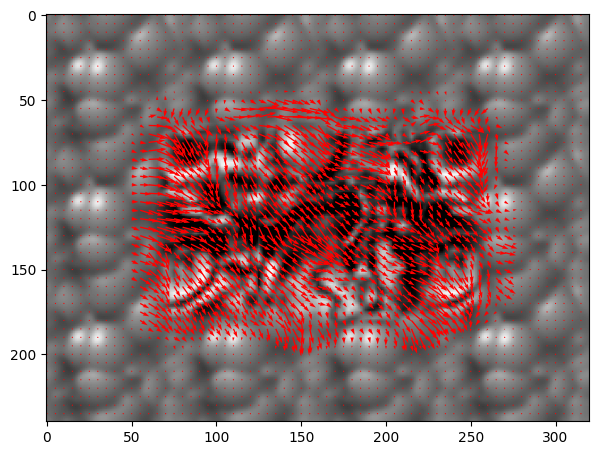

In [10]:
V = LK_optic_flow(img1, img3, 17)
plt.figure(figsize=(7, 8))
plt.imshow(img1, cmap='gray')
plt.quiver(np.arange(0, img1.shape[1], 5), np.arange(0, img1.shape[0], 5), V[::5, ::5, 0], V[::5, ::5, 1], color='r')
plt.show()

## Test On Higher Shift

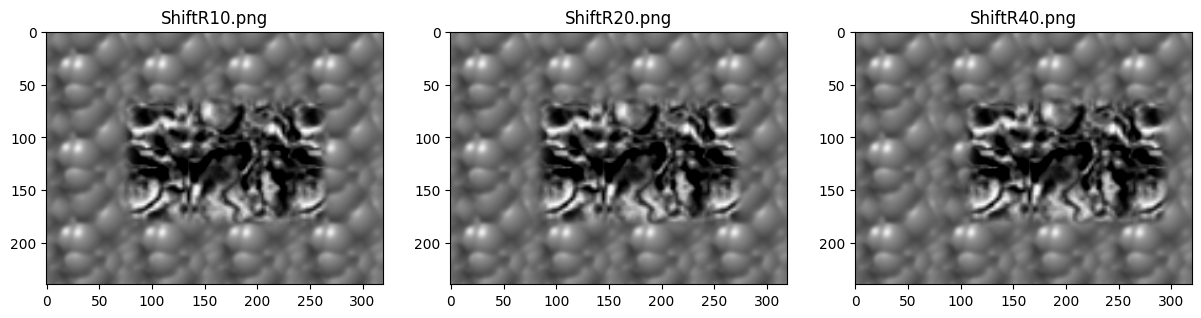

In [11]:
img_R10 = cv2.imread('TestSeq/ShiftR10.png', cv2.IMREAD_GRAYSCALE)
img_R20 = cv2.imread('TestSeq/ShiftR20.png', cv2.IMREAD_GRAYSCALE)
img_R40 = cv2.imread('TestSeq/ShiftR40.png', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(20,20))
plt.subplot(141)
plt.imshow(img_R10, cmap='gray')
plt.title('ShiftR10.png')
plt.subplot(142)
plt.imshow(img_R20, cmap='gray')
plt.title('ShiftR20.png')
plt.subplot(143)
plt.imshow(img_R40, cmap='gray')
plt.title('ShiftR40.png')
plt.show()

Calculating Optical Flow: 100%|██████████| 200/200 [00:01<00:00, 141.85it/s]


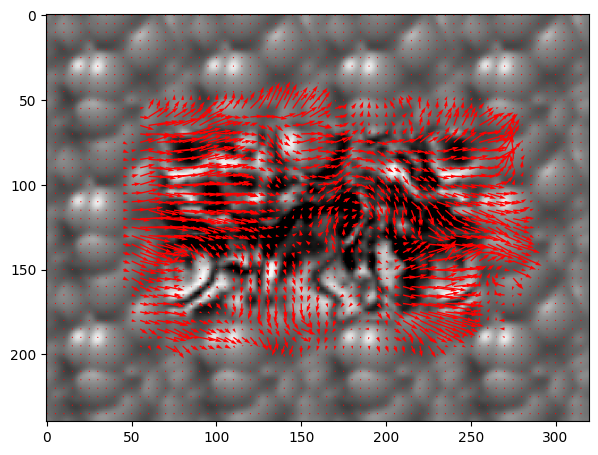

In [12]:
V = LK_optic_flow(img1, img_R10, 20)
plt.figure(figsize=(7, 8))
plt.imshow(img1, cmap='gray')
plt.quiver(np.arange(0, img1.shape[1], 5), np.arange(0, img1.shape[0], 5), V[::5, ::5, 0], V[::5, ::5, 1], color='r')
plt.show()

Calculating Optical Flow: 100%|██████████| 200/200 [00:01<00:00, 147.85it/s]


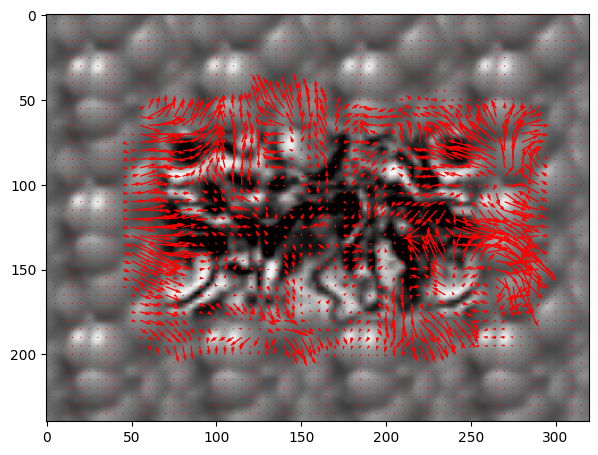

In [13]:
V = LK_optic_flow(img1, img_R20, 20)
plt.figure(figsize=(7, 8))
plt.imshow(img1, cmap='gray')
plt.quiver(np.arange(0, img1.shape[1], 5), np.arange(0, img1.shape[0], 5), V[::5, ::5, 0], V[::5, ::5, 1], color='r')
plt.show()

Calculating Optical Flow: 100%|██████████| 200/200 [00:01<00:00, 148.49it/s]


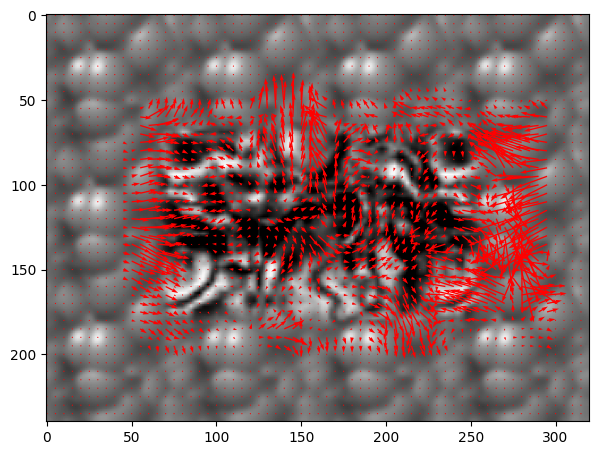

In [14]:
V = LK_optic_flow(img1, img_R40, 20)
plt.figure(figsize=(7, 8))
plt.imshow(img1, cmap='gray')
plt.quiver(np.arange(0, img1.shape[1], 5), np.arange(0, img1.shape[0], 5), V[::5, ::5, 0], V[::5, ::5, 1], color='r')
plt.show()

## Part 2 Gaussian Pyramids

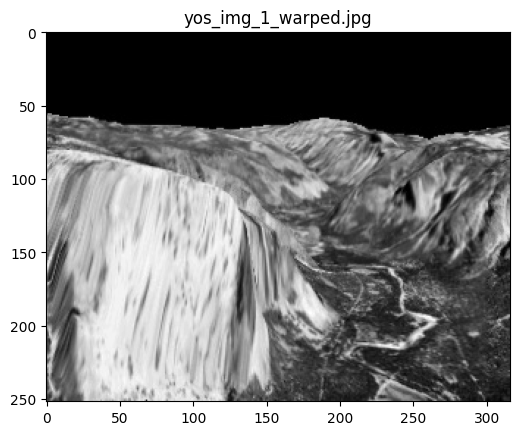

In [15]:
yos_img_1_wraped = cv2.imread('DataSeq1/yos_img_1_warped.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(yos_img_1_wraped, cmap='gray')
plt.title('yos_img_1_warped.jpg')
plt.show()

In [16]:
def five_tap_Reduce(img):
    kernel = np.array([1, 4, 6, 4, 1])/16
    img = cv2.filter2D(img, -1, kernel.reshape(-1, 1))
    img = cv2.filter2D(img, -1, kernel.reshape(1, -1))
    img = img[::2, ::2]
    return img

In [17]:
def gaussian_pyramid(img, levels):
    pyramid = [img]
    for _ in range(levels):
        img = cv2.GaussianBlur(img, (5, 5), 1)
        img = five_tap_Reduce(img)
        pyramid.append(img)
    return pyramid

In [18]:
def display_gaussian_pyramid(img, levels):
    pyramid = gaussian_pyramid(img, levels)
    plt.figure(figsize=(20, 20))
    for i in range(levels+1):
        plt.subplot(1, 1 + levels, i+1)
        plt.imshow(pyramid[i], cmap='gray')
        plt.title(f'Level {i}')
    plt.show()

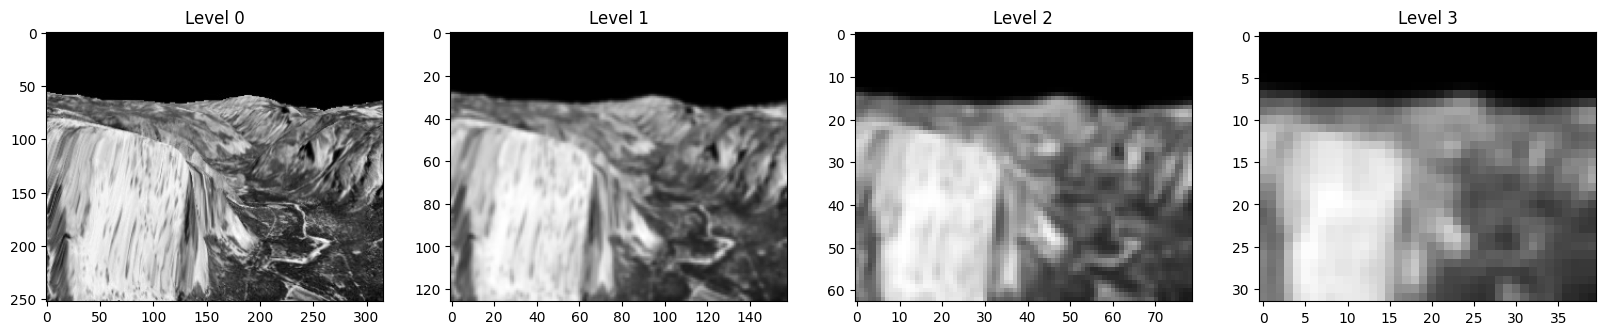

In [19]:
display_gaussian_pyramid(yos_img_1_wraped, 3)

In [20]:
def three_tap_expand(img):
    kernel = np.array([1, 2, 1])/4
    img = np.repeat(img, 2, axis=0)
    img = np.repeat(img, 2, axis=1)
    img = cv2.filter2D(img, -1, kernel.reshape(-1, 1))
    img = cv2.filter2D(img, -1, kernel.reshape(1, -1))
    return img

In [21]:
def laplacian_pyramid(img, levels):
    pyramid = []
    gaussian_pyramid_result = gaussian_pyramid(img, levels)
    for i in range(levels - 1):
        expanded = three_tap_expand(gaussian_pyramid_result[i + 1])
        expanded = expanded[:gaussian_pyramid_result[i].shape[0], :gaussian_pyramid_result[i].shape[1]]
        laplacian = gaussian_pyramid_result[i].astype(np.float64) - expanded.astype(np.float64)
        pyramid.append(laplacian)
    pyramid.append(gaussian_pyramid_result[-2])
    return pyramid

In [22]:
def display_laplacian_pyramid(img, levels):
    pyramid = laplacian_pyramid(img, levels)
    plt.figure(figsize=(20, 20))
    for i in range(levels):
        plt.subplot(1, 1 + levels, i+1)
        plt.imshow(pyramid[i], cmap='gray')
        plt.title(f'Level {i}')
    plt.show()

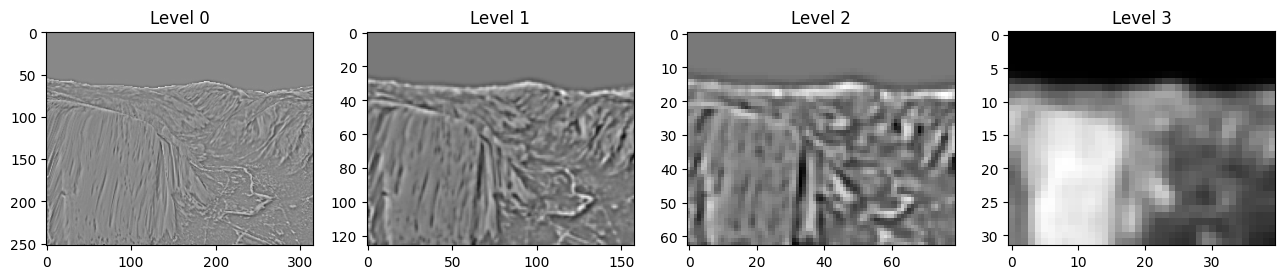

In [23]:
display_laplacian_pyramid(yos_img_1_wraped, 4)

In [24]:
img_laplacian_pyramid = laplacian_pyramid(yos_img_1_wraped, 4)

In [25]:
def reconstruct_img(img_laplacian_pyramid):
    img = img_laplacian_pyramid[-1].astype(np.float64)
    for i in range(len(img_laplacian_pyramid) - 2, -1, -1):
        expanded = three_tap_expand(img)
        expanded = expanded[:img_laplacian_pyramid[i].shape[0], :img_laplacian_pyramid[i].shape[1]]
        img = img_laplacian_pyramid[i].astype(np.float64) + expanded.astype(np.float64)
    return img

## Warp the Flow

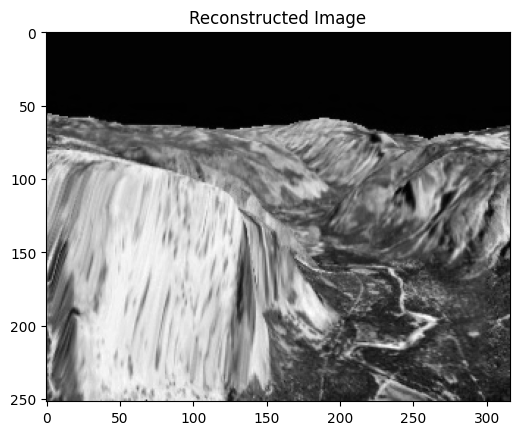

In [26]:
reconstructed_img = reconstruct_img(img_laplacian_pyramid)
plt.imshow(reconstructed_img, cmap='gray')
plt.title('Reconstructed Image')
plt.show()

In [99]:
def warp_images(img2, V):
    h, w = img2.shape
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    warpI2 = cv2.remap(img2, (x + V[:, :, 0]).astype(np.float32),
                           (y + V[:, :, 1]).astype(np.float32), cv2.INTER_LINEAR)
    warpI3 = cv2.remap(img2, (x + V[:, :, 0]).astype(np.float32),
                           (y + V[:, :, 1]).astype(np.float32), cv2.INTER_NEAREST)
    mask = np.isnan(warpI2)
    warpI2[mask] = warpI3[mask]
    return warpI2

Calculating Optical Flow: 100%|██████████| 460/460 [00:06<00:00, 75.78it/s]


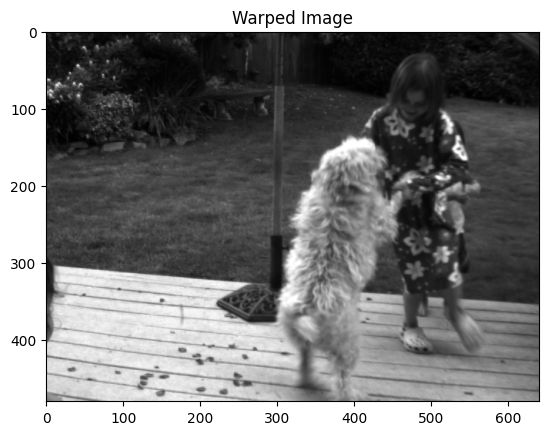

In [100]:
V = LK_optic_flow(img1, img2, 10)
warped_img = warp_images(img1, V)
plt.imshow(warped_img, cmap='gray')
plt.title('Warped Image')
plt.imsave('TestSeq/warped_img.png', warped_img, cmap='gray')
plt.show()

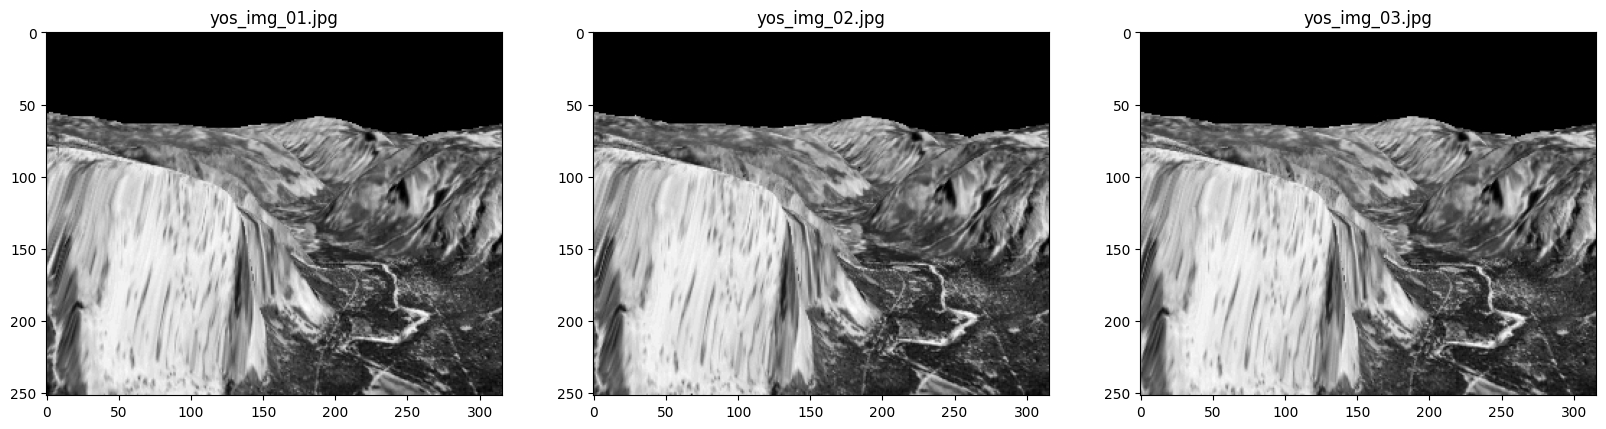

In [101]:
yos_img1 = cv2.imread('DataSeq1/yos_img_01.jpg', cv2.IMREAD_GRAYSCALE)
yos_img2 = cv2.imread('DataSeq1/yos_img_02.jpg', cv2.IMREAD_GRAYSCALE)
yos_img3 = cv2.imread('DataSeq1/yos_img_03.jpg', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(20,20))
plt.subplot(131)
plt.imshow(yos_img1, cmap='gray')
plt.title('yos_img_01.jpg')
plt.subplot(132)
plt.imshow(yos_img2, cmap='gray')
plt.title('yos_img_02.jpg')
plt.subplot(133)
plt.imshow(yos_img3, cmap='gray')
plt.title('yos_img_03.jpg')
plt.show()

In [102]:
yos_img1_gaussian_pyramid = gaussian_pyramid(yos_img1, 4)
yos_img2_gaussian_pyramid = gaussian_pyramid(yos_img2, 4)
yos_img3_gaussian_pyramid = gaussian_pyramid(yos_img3, 4)

In [103]:
def perform_LK_on_pyramids(img1_pyramid, img2_pyramid):
    flow_pyramid = []
    for i in range(len(img1_pyramid) - 1):
        V = LK_optic_flow(img1_pyramid[i], img2_pyramid[i], 10)
        flow_pyramid.append(V) 
    return flow_pyramid

Calculating Optical Flow: 100%|██████████| 12/12 [00:00<00:00, 2304.14it/s]


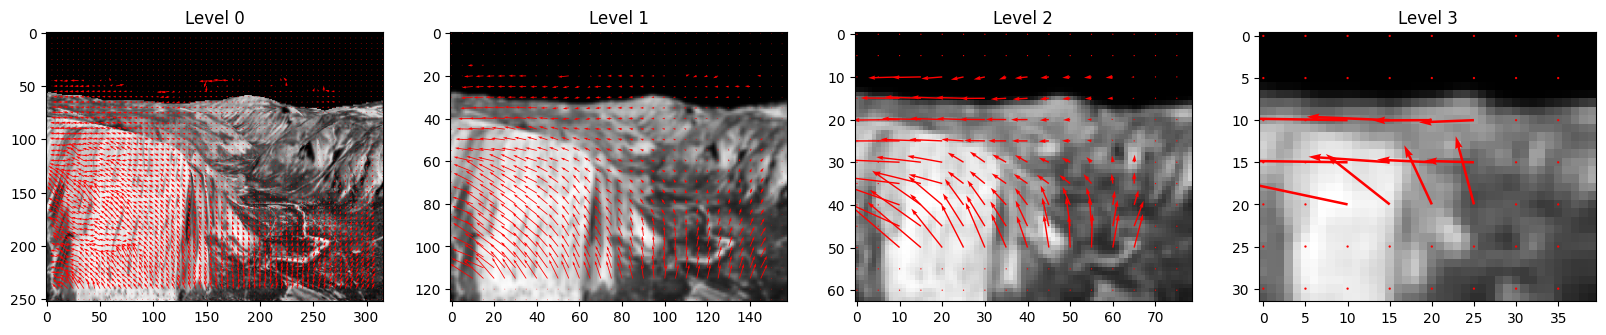

In [104]:
flow_pyramid = perform_LK_on_pyramids(yos_img1_gaussian_pyramid, yos_img2_gaussian_pyramid)
plt.figure(figsize=(20, 20))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(yos_img1_gaussian_pyramid[i], cmap='gray')
    plt.quiver(np.arange(0, yos_img1_gaussian_pyramid[i].shape[1], 5), 
               np.arange(0, yos_img1_gaussian_pyramid[i].shape[0], 5), 
               flow_pyramid[i][::5, ::5, 0], flow_pyramid[i][::5, ::5, 1], color='r')
    plt.title(f'Level {i}')
plt.show()

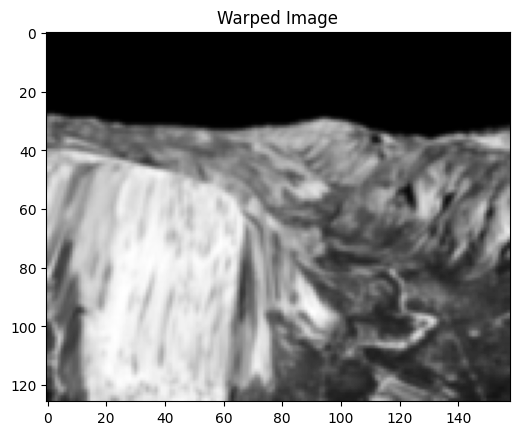

In [105]:
level_1_yos_img1 = yos_img1_gaussian_pyramid[1]
level_1_yos_img2 = yos_img2_gaussian_pyramid[1]
wraped_img = warp_images(level_1_yos_img1, flow_pyramid[1])
plt.imshow(wraped_img, cmap='gray')
plt.imsave('DataSeq1/yos_warped_img.png', wraped_img, cmap='gray')
plt.title('Warped Image')
plt.show()

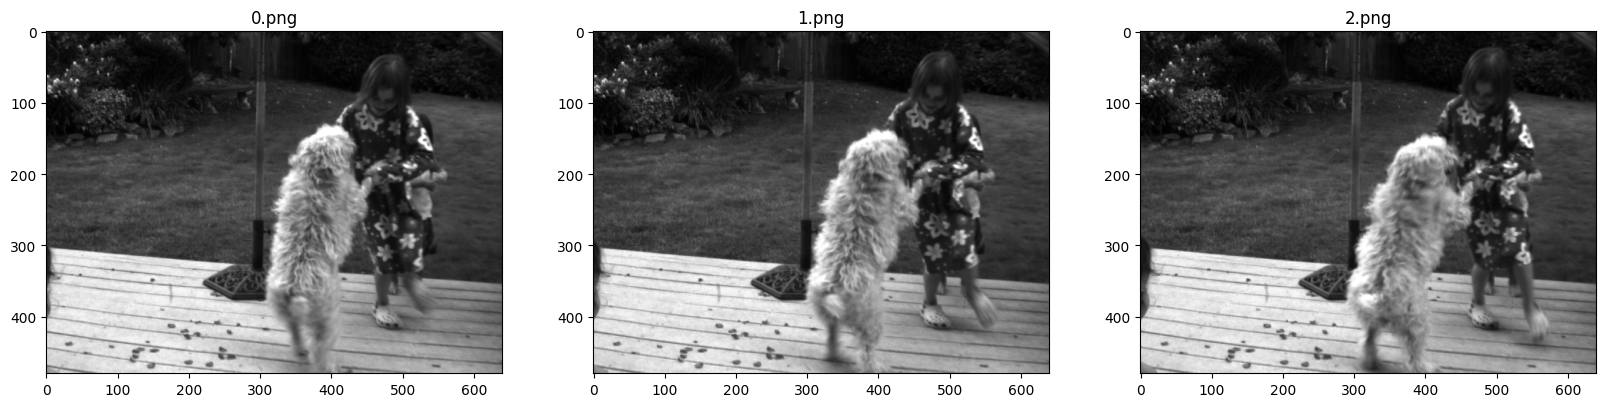

In [106]:
img0 = cv2.imread('DataSeq2/0.png', cv2.IMREAD_GRAYSCALE)
img1 = cv2.imread('DataSeq2/1.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('DataSeq2/2.png', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(20,20))
plt.subplot(131)
plt.imshow(img0, cmap='gray')
plt.title('0.png')
plt.subplot(132)
plt.imshow(img1, cmap='gray')
plt.title('1.png')
plt.subplot(133)
plt.imshow(img2, cmap='gray')
plt.title('2.png')
plt.show()

In [35]:
img0_gaussian_pyramid = gaussian_pyramid(img0, 4)
img1_gaussian_pyramid = gaussian_pyramid(img1, 4)
img2_gaussian_pyramid = gaussian_pyramid(img2, 4)

Calculating Optical Flow: 100%|██████████| 40/40 [00:00<00:00, 779.77it/s]


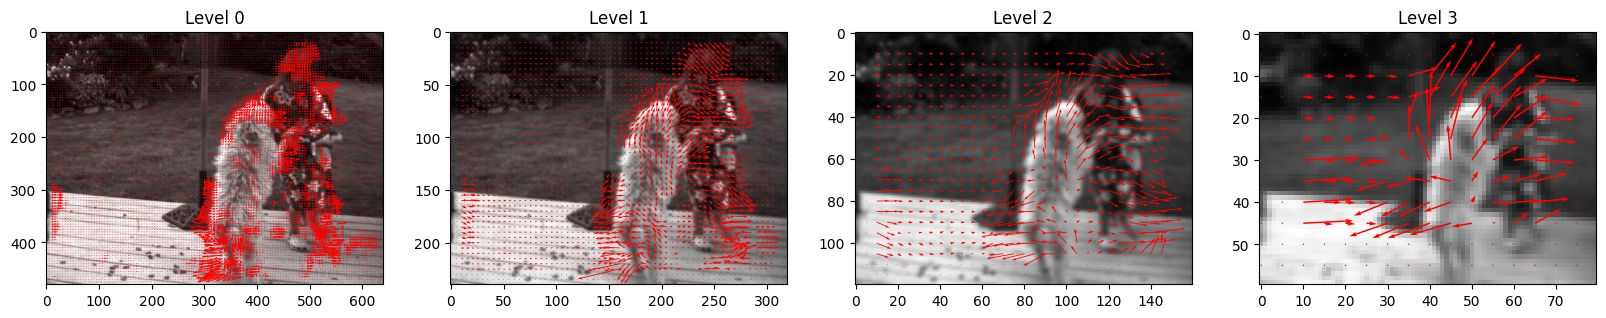

In [36]:
flow_pyramid = perform_LK_on_pyramids(img0_gaussian_pyramid, img1_gaussian_pyramid)
plt.figure(figsize=(20, 20))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(img0_gaussian_pyramid[i], cmap='gray')
    plt.quiver(np.arange(0, img0_gaussian_pyramid[i].shape[1], 5), 
               np.arange(0, img0_gaussian_pyramid[i].shape[0], 5), 
               flow_pyramid[i][::5, ::5, 0], flow_pyramid[i][::5, ::5, 1], color='r')
    plt.title(f'Level {i}')

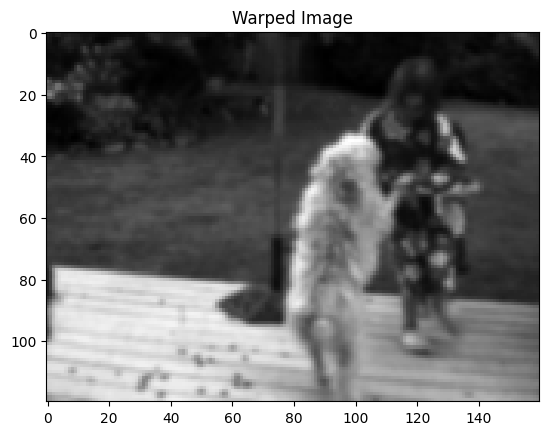

In [37]:
level_2_img0 = img0_gaussian_pyramid[2] 
level_2_img1 = img1_gaussian_pyramid[2]
wraped_img = warp_images(level_2_img0, flow_pyramid[2])
plt.imshow(wraped_img, cmap='gray')
plt.imsave('DataSeq2/level_2_img1.png', level_2_img1, cmap='gray')
plt.imsave('DataSeq2/warped_img.png', wraped_img, cmap='gray')
plt.title('Warped Image')
plt.show()

## Hierarchial LK

In [107]:
def hierarchialLK(img1, img2, levels=4, box_size=10):
    gaussian_pyramid_img1 = gaussian_pyramid(img1, levels)
    gaussian_pyramid_img2 = gaussian_pyramid(img2, levels)
    for i in reversed(range(levels)):
        if i == levels - 1:
            V = LK_optic_flow(gaussian_pyramid_img1[i], gaussian_pyramid_img2[i], box_size)
        else:
            V = three_tap_expand(V) * 2
            W_k = warp_images(gaussian_pyramid_img1[i], V)
            V += LK_optic_flow(W_k, gaussian_pyramid_img2[i], box_size)
    return V

Calculating Optical Flow: 100%|██████████| 220/220 [00:01<00:00, 155.11it/s]


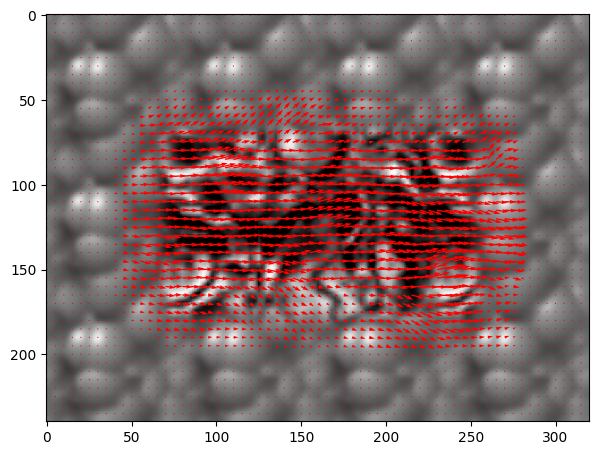

In [125]:
img_shift0 = cv2.imread('TestSeq/Shift0.png', cv2.IMREAD_GRAYSCALE)
V = hierarchialLK(img_shift0, img_R10, levels=4, box_size=10)
plt.figure(figsize=(7, 8))
plt.imshow(img_shift0, cmap='gray')
plt.quiver(np.arange(0, img_shift0.shape[1], 5), np.arange(0, img_shift0.shape[0], 5), V[::5, ::5, 0], V[::5, ::5, 1], color='r')
plt.show()

Calculating Optical Flow: 100%|██████████| 220/220 [00:01<00:00, 157.24it/s]


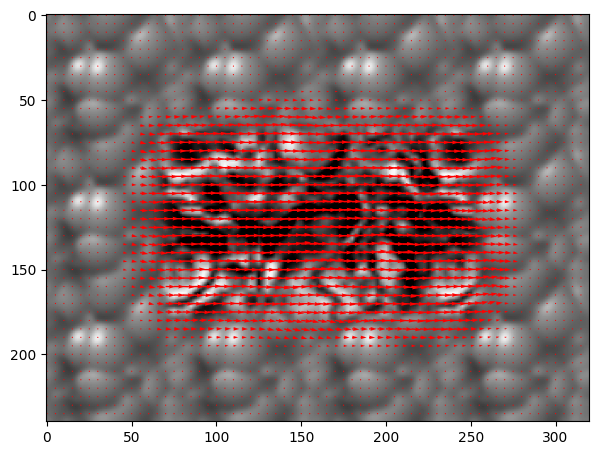

In [109]:
img_shift2 = cv2.imread('TestSeq/ShiftR2.png', cv2.IMREAD_GRAYSCALE)
V = hierarchialLK(img_shift0, img_shift2, levels=4, box_size=10)
plt.figure(figsize=(7, 8))
plt.imshow(img_shift0, cmap='gray')
plt.quiver(np.arange(0, img_shift0.shape[1], 5), np.arange(0, img_shift0.shape[0], 5), V[::5, ::5, 0], V[::5, ::5, 1], color='r')
plt.show()

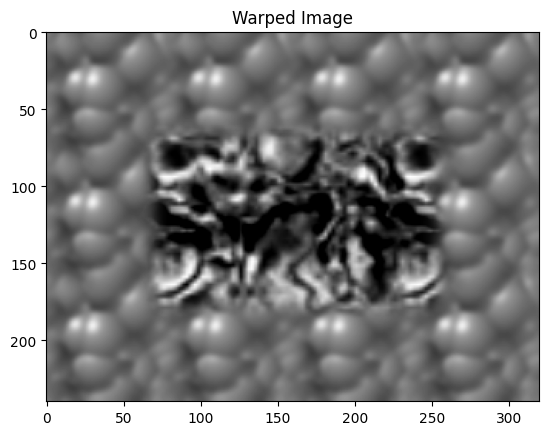

In [112]:
warped_img = warp_images(img_shift2, V)
plt.imsave('TestSeq/warped_img.png', warped_img, cmap='gray')
plt.imshow(warped_img, cmap='gray')
plt.title('Warped Image')
plt.show()

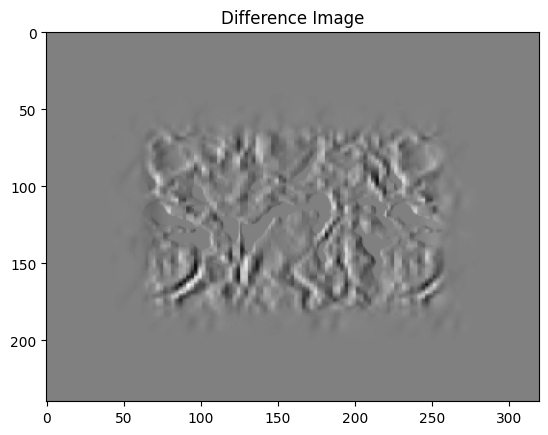

In [113]:
diff = img_shift0.astype(np.float64) - warped_img.astype(np.float64)
plt.imshow(diff, cmap='gray')
plt.title('Difference Image')
plt.show()

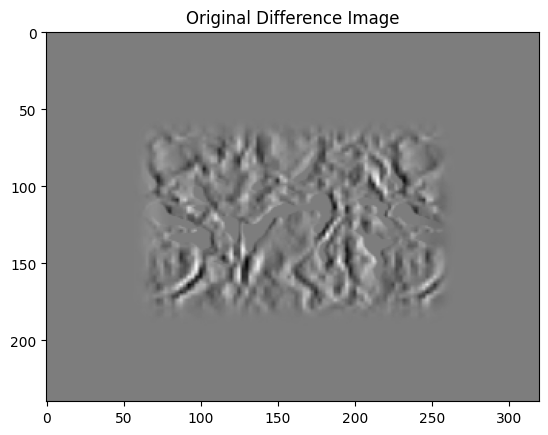

In [114]:
original_diff = img_shift2.astype(np.float64) - img_shift0.astype(np.float64)
plt.imshow(original_diff, cmap='gray')
plt.title('Original Difference Image')
plt.show()

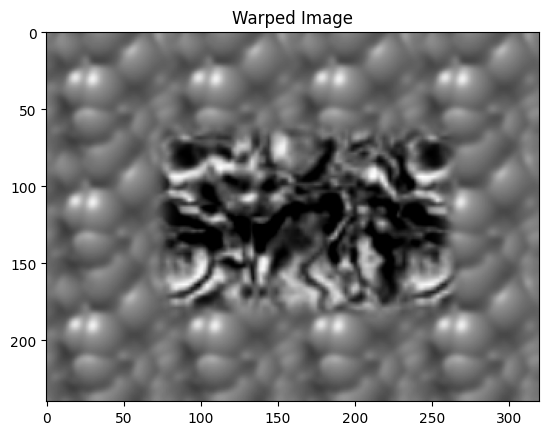

In [126]:
warped_img = warp_images(img_R10, V)
plt.imshow(warped_img, cmap='gray')
plt.imsave('TestSeq/warped_img.png', warped_img, cmap='gray')
plt.title('Warped Image')
plt.show()

Calculating Optical Flow: 100%|██████████| 220/220 [00:01<00:00, 156.72it/s]


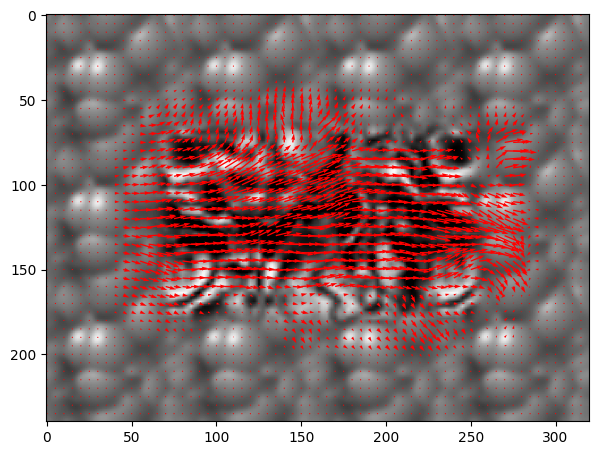

In [47]:
V = hierarchialLK(img_shift0, img_R20, levels=4, box_size=10)
plt.figure(figsize=(7, 8))
plt.imshow(img_shift0, cmap='gray')
plt.quiver(np.arange(0, img_shift0.shape[1], 5), np.arange(0, img_shift0.shape[0], 5), V[::5, ::5, 0], V[::5, ::5, 1], color='r')
plt.show()

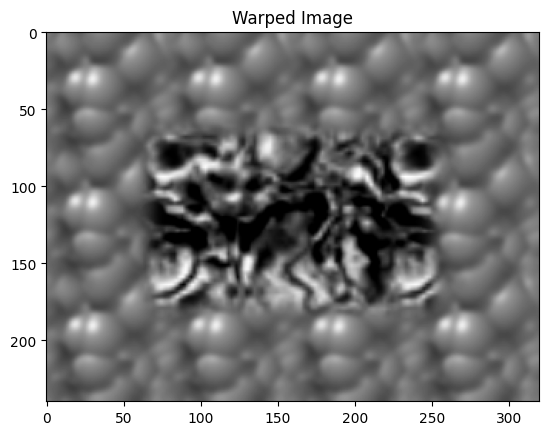

In [48]:
warped_img = warp_images(img_shift0, V)
plt.imshow(warped_img, cmap='gray')
plt.imsave('TestSeq/hierarchial_warped_img.png', warped_img, cmap='gray')
plt.title('Warped Image')
plt.show()

In [49]:
def min_max_normalize(img):
    return (img - np.min(img))/(np.max(img) - np.min(img))

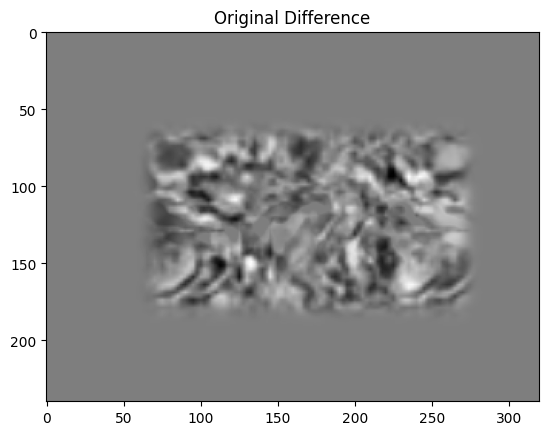

Mean Squared Error: 0.2520329038262621


In [50]:
original_diff = img_shift0.astype(np.float64) - img_R20.astype(np.float64)
original_diff = min_max_normalize(original_diff)
plt.imshow(original_diff, cmap='gray')
plt.title('Original Difference')
plt.show()
print('Mean Squared Error:', np.mean(original_diff**2))

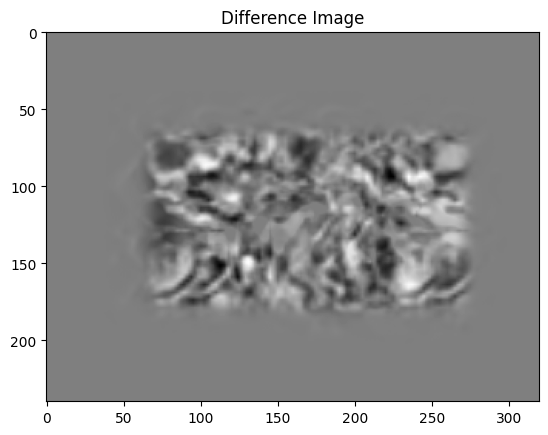

Mean Squared Error: 0.25329555542088883


In [51]:
diff = warped_img.astype(np.float64) - img_R20.astype(np.float64)
diff = min_max_normalize(diff)
plt.imshow(diff, cmap='gray')
plt.title('Difference Image')
plt.show()
print('Mean Squared Error:', np.mean(diff**2))

In [67]:
mse = np.mean(diff**2)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 39.006497395833335


Calculating Optical Flow: 100%|██████████| 230/230 [00:01<00:00, 159.52it/s]


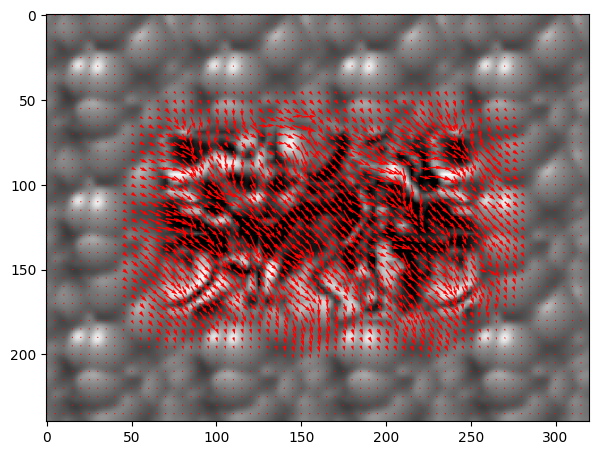

In [115]:
img_R5U5 = cv2.imread('TestSeq/ShiftR5U5.png', cv2.IMREAD_GRAYSCALE)
V = hierarchialLK(img_shift0, img_R5U5, levels=4, box_size=5)
plt.figure(figsize=(7, 8))
plt.imshow(img_shift0, cmap='gray')
plt.quiver(np.arange(0, img_shift0.shape[1], 5), np.arange(0, img_shift0.shape[0], 5), V[::5, ::5, 0], V[::5, ::5, 1], color='r')
plt.show()

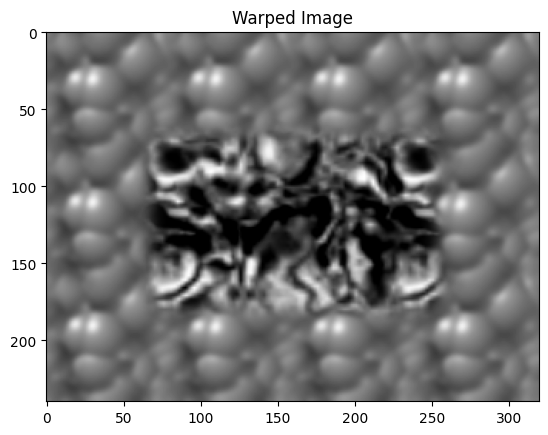

In [117]:
warped_img = warp_images(img_shift2, V)
plt.imshow(warped_img, cmap='gray')
plt.imsave('TestSeq/hierarchial_warped_img.png', warped_img, cmap='gray')
plt.title('Warped Image')
plt.show()

Calculating Optical Flow: 100%|██████████| 472/472 [00:06<00:00, 78.66it/s]


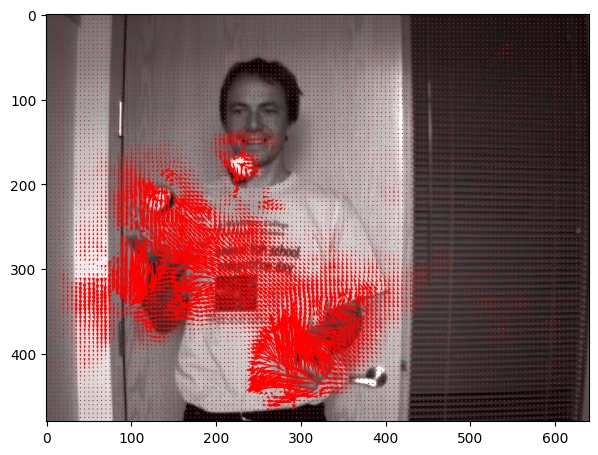

In [138]:
juggle_img0 = cv2.imread('Juggle/0.png', cv2.IMREAD_GRAYSCALE)
juggle_img1 = cv2.imread('Juggle/1.png', cv2.IMREAD_GRAYSCALE)
V = hierarchialLK(juggle_img0, juggle_img1, levels=6, box_size=4)
plt.figure(figsize=(7, 8))
plt.imshow(juggle_img1, cmap='gray')
plt.quiver(np.arange(0, juggle_img0.shape[1], 5), np.arange(0, juggle_img0.shape[0], 5), V[::5, ::5, 0], V[::5, ::5, 1], color='r')
plt.show()

In [139]:
V[:, :,0].min()

-44.69413144224518

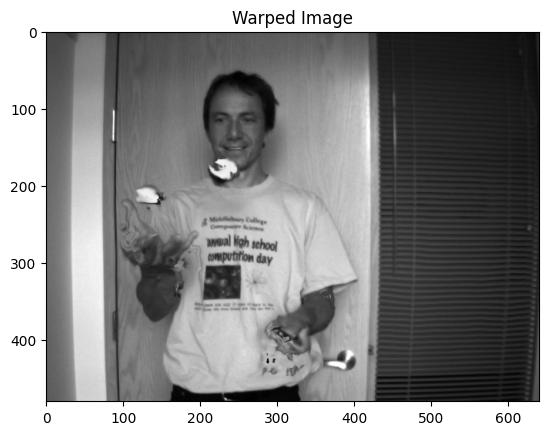

In [140]:
warped_img = warp_images(juggle_img1, V)
plt.imshow(warped_img, cmap='gray')
plt.imsave('Juggle/hierarchial_warped_img.png', warped_img, cmap='gray')
plt.title('Warped Image')
plt.show()